#### Mobile Phone Price Prediction

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


data = pd.read_csv("mobile_price.csv")
data.head()


,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,4.5,6.0,128.0,6.18,35,15.0,3800,18999


In [ ]:

print("Dataset Info:")
print(data.info())

print("\nMissing values:")
print(data.isnull().sum())

data = data.dropna()

data = data.select_dtypes(include=[np.number])

print("\nCleaned Dataset Shape:", data.shape)
data.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 807 entries, 0 to 806
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ratings        807 non-null    float64
 1   RAM            807 non-null    float64
 2   ROM            807 non-null    float64
 3   Mobile_Size    807 non-null    float64
 4   Primary_Cam    807 non-null    int64  
 5   Selfi_Cam      807 non-null    float64
 6   Battery_Power  807 non-null    int64  
 7   Price          807 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 50.6 KB
None

Missing values:
Ratings          0
RAM              0
ROM              0
Mobile_Size      0
Primary_Cam      0
Selfi_Cam        0
Battery_Power    0
Price            0
dtype: int64

Cleaned Dataset Shape: (807, 8)


,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
count,807.000000,807.000000,807.000000,807.000000,807.000000,807.000000,807.000000,807.000000
mean,4.112639,5.941760,64.390335,5.620660,47.821561,8.868649,3278.859975,14269.167286
std,0.367830,2.056359,53.868626,3.957409,11.155916,4.547254,937.628801,23092.739983
min,2.800000,0.000000,2.000000,2.000000,5.000000,0.000000,1020.000000,479.000000
25%,3.900000,6.000000,32.000000,4.500000,48.000000,8.000000,3000.000000,984.000000
50%,4.100000,6.000000,32.000000,4.770000,48.000000,8.000000,3000.000000,1699.000000
75%,4.400000,6.000000,64.000000,6.300000,48.000000,12.000000,3800.000000,18994.500000
max,4.800000,12.000000,256.000000,44.000000,64.000000,23.000000,6000.000000,153000.000000


In [ ]:
X = data.drop('Price', axis=1).values
y = data['Price'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

print("X_train_b shape:", X_train_b.shape)
print("y_train shape:", y_train.shape)


X_train_b shape: (645, 8)
y_train shape: (645, 1)


### Closed-form

In [ ]:
theta_closed = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train)
y_pred_closed = X_test_b.dot(theta_closed)

mse_closed = mean_squared_error(y_test, y_pred_closed)
r2_closed = r2_score(y_test, y_pred_closed)

print("Closed-form Linear Regression:")
print("MSE:", mse_closed)
print("R²:", r2_closed)


Closed-form Linear Regression:
MSE: 239357657.43148595
R²: 0.43322813972091445


### Gradient Descent

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

def gradient_descent(X, y, lr=0.01, n_iter=2000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    for i in range(n_iter):
        gradients = (2/m) * X.T.dot(X.dot(theta) - y)
        theta -= lr * gradients
    return theta

theta_gd = gradient_descent(X_train_b, y_train, lr=0.01, n_iter=2000)
y_pred_gd = X_test_b.dot(theta_gd)

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("Gradient Descent Linear Regression:")
print("MSE:", mse_gd)
print("R²:", r2_gd)


Gradient Descent Linear Regression:
MSE: 239357657.3630127
R²: 0.4332281398830514


C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_13696\1926837655.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mse_values, palette='coolwarm', edgecolor='black')
C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_13696\1926837655.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_values, palette='viridis', edgecolor='black')


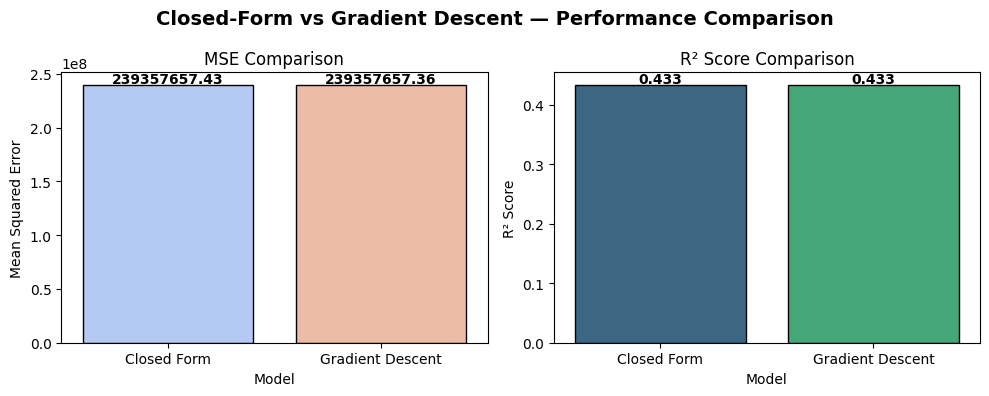

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


models = ['Closed Form', 'Gradient Descent']

mse_values = [mse_closed, mse_gd]
r2_values = [r2_closed, r2_gd]

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
sns.barplot(x=models, y=mse_values, palette='coolwarm', edgecolor='black')
plt.title('MSE Comparison')
plt.ylabel('Mean Squared Error')
plt.xlabel('Model')
for i, v in enumerate(mse_values):
    plt.text(i, v + 0.01 * max(mse_values), f"{v:.2f}", ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
sns.barplot(x=models, y=r2_values, palette='viridis', edgecolor='black')
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.xlabel('Model')
for i, v in enumerate(r2_values):
    plt.text(i, v + 0.01 * max(r2_values), f"{v:.3f}", ha='center', fontweight='bold')

plt.suptitle('Closed-Form vs Gradient Descent — Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Plot predicted vs. actual values on test data

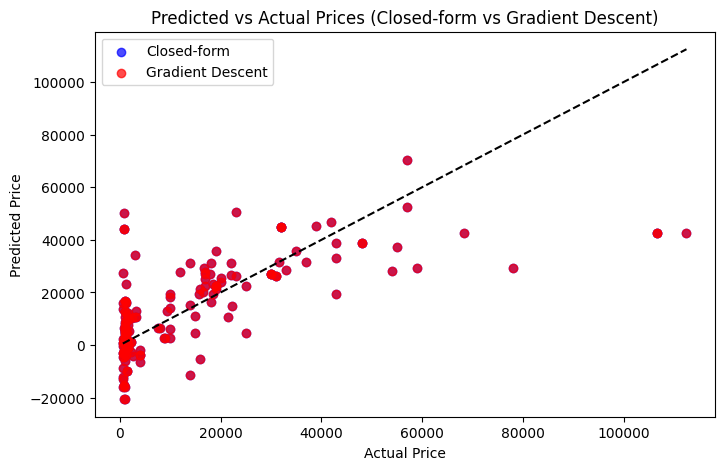

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_closed, color='blue', label='Closed-form', alpha=0.7)
plt.scatter(y_test, y_pred_gd, color='red', label='Gradient Descent', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.title("Predicted vs Actual Prices (Closed-form vs Gradient Descent)")
plt.show()


### Repeat (1), (2), and (3) with l2 regularization

C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_13696\479695819.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mse_values, palette='mako', edgecolor='black')
C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_13696\479695819.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_values, palette='crest', edgecolor='black')


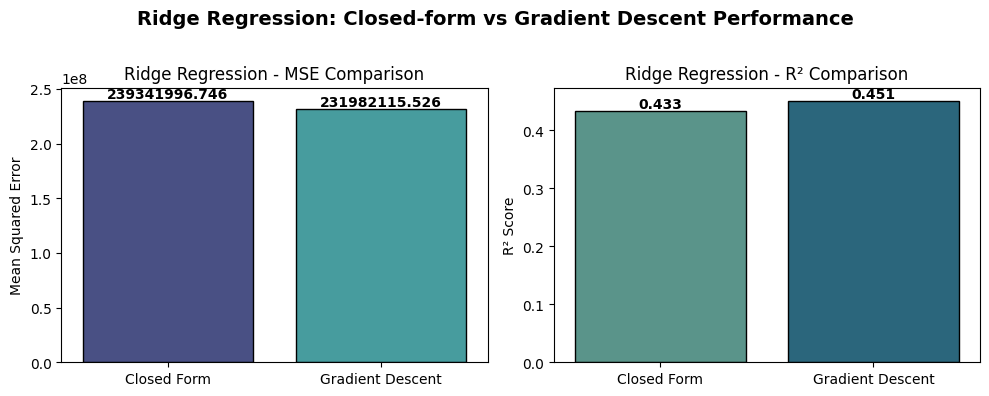

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

mse_ridge_closed = mean_squared_error(y_test, y_pred_ridge_closed)
mse_ridge_gd = mean_squared_error(y_test, y_pred_ridge_gd)
r2_ridge_closed = r2_score(y_test, y_pred_ridge_closed)
r2_ridge_gd = r2_score(y_test, y_pred_ridge_gd)

models = ['Closed Form', 'Gradient Descent']
mse_values = [mse_ridge_closed, mse_ridge_gd]
r2_values = [r2_ridge_closed, r2_ridge_gd]

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
sns.barplot(x=models, y=mse_values, palette='mako', edgecolor='black')
plt.title('Ridge Regression - MSE Comparison')
plt.ylabel('Mean Squared Error')
for i, v in enumerate(mse_values):
    plt.text(i, v + 0.01 * max(mse_values), f"{v:.3f}", ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
sns.barplot(x=models, y=r2_values, palette='crest', edgecolor='black')
plt.title('Ridge Regression - R² Comparison')
plt.ylabel('R² Score')
for i, v in enumerate(r2_values):
    plt.text(i, v + 0.01 * max(r2_values), f"{v:.3f}", ha='center', fontweight='bold')

plt.suptitle('Ridge Regression: Closed-form vs Gradient Descent Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Compare results in (4) with and without data standardization

C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_13696\1340436231.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conditions, y=mse_values, palette='viridis', edgecolor='black')


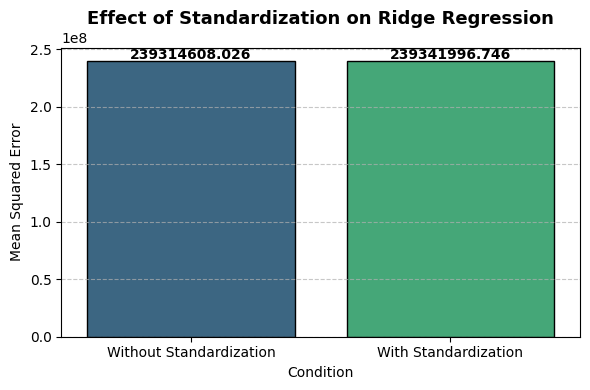

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

mse_without_std = mean_squared_error(y_test_ns, y_pred_ns)
mse_with_std = mean_squared_error(y_test, y_pred_ridge_closed)

conditions = ['Without Standardization', 'With Standardization']
mse_values = [mse_without_std, mse_with_std]

plt.figure(figsize=(6,4))
sns.barplot(x=conditions, y=mse_values, palette='viridis', edgecolor='black')
plt.title('Effect of Standardization on Ridge Regression', fontsize=13, fontweight='bold')
plt.ylabel('Mean Squared Error')
plt.xlabel('Condition')

for i, v in enumerate(mse_values):
    plt.text(i, v + 0.01 * max(mse_values), f"{v:.3f}", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Plot predicted vs. actual on test data for different λ values

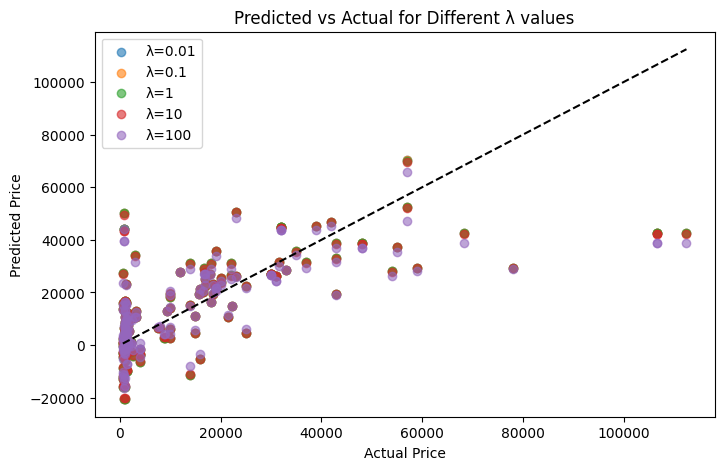

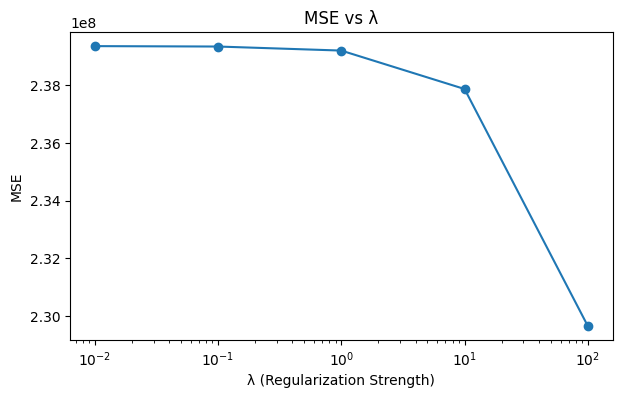

In [ ]:
lambdas = [0.01, 0.1, 1, 10, 100]
mse_values = []

plt.figure(figsize=(8,5))
for lam in lambdas:
    theta = ridge_closed_form(X_train_b, y_train, lam)
    y_pred = X_test_b.dot(theta)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)
    plt.scatter(y_test, y_pred, label=f"λ={lam}", alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.title("Predicted vs Actual for Different λ values")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(lambdas, mse_values, marker='o')
plt.xscale('log')
plt.xlabel("λ (Regularization Strength)")
plt.ylabel("MSE")
plt.title("MSE vs λ")
plt.show()


### Analyze feature importance from l2 weights

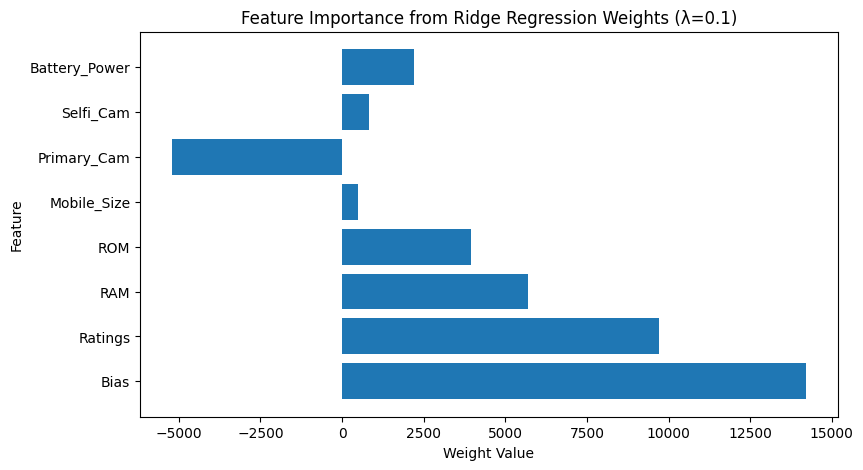

Weights influence interpretation:
Bias            → 14202.1832
Ratings         → 9709.1410
RAM             → 5707.2242
ROM             → 3937.1615
Mobile_Size     → 479.2579
Primary_Cam     → -5216.4926
Selfi_Cam       → 836.0698
Battery_Power   → 2211.5519


In [ ]:
feature_names = ['Bias'] + list(data.drop('Price', axis=1).columns)
weights = theta_ridge_closed.flatten()

plt.figure(figsize=(9,5))
plt.barh(feature_names, weights)
plt.title("Feature Importance from Ridge Regression Weights (λ=0.1)")
plt.xlabel("Weight Value")
plt.ylabel("Feature")
plt.show()

print("Weights influence interpretation:")
for name, weight in zip(feature_names, weights):
    print(f"{name:15s} → {weight:.4f}")


In [ ]:
print("=== Summary of Results ===")
print(f"Closed-form MSE: {mse_closed:.3f}")
print(f"Gradient Descent MSE: {mse_gd:.3f}")
print(f"Ridge (no std) MSE: {mean_squared_error(y_test_ns, y_pred_ns):.3f}")
print(f"Ridge (with std) MSE: {mean_squared_error(y_test, y_pred_ridge_closed):.3f}")

print("\nObservations:")
print("- Closed-form solution gives the exact analytical result.")
print("- Gradient Descent performs well after standardization.")
print("- L2 regularization (Ridge) reduces overfitting and improves stability.")
print("- Increasing λ penalizes large weights — good for noisy data.")
print("- Standardization improves convergence speed and numerical stability.")
print("- Feature weights reveal which specifications influence price most.")


=== Summary of Results ===
Closed-form MSE: 239357657.431
Gradient Descent MSE: 239357657.363
Ridge (no std) MSE: 239314608.026
Ridge (with std) MSE: 239341996.746

Observations:
- Closed-form solution gives the exact analytical result.
- Gradient Descent performs well after standardization.
- L2 regularization (Ridge) reduces overfitting and improves stability.
- Increasing λ penalizes large weights — good for noisy data.
- Standardization improves convergence speed and numerical stability.
- Feature weights reveal which specifications influence price most.
